In [ ]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import numpy as np
from scipy.stats import randint
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer
from pandas.plotting import scatter_matrix
print("LIBRARIES IMPORTED")


LIBRARIES IMPORTED


## EDA ##

In [334]:
data = pd.read_csv("https://raw.githubusercontent.com/semingrai/Hands-on-ML-/main/CHp1-2/c4.csv")

In [335]:
data.head(3)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0


In [336]:
data["Engine"] = data["Engine"].str.extract(r'(\d+)').astype(float)
data["Max Torque(bhp)"] = data["Max Torque"].str.extract(r'(\d+)').astype(float)
data["Max Power(Nm)"] = data["Max Power"].str.extract(r'(\d+)').astype(float)

In [337]:
data["Max Power(rpm)"] = data["Max Power"].str.extract(r'@\s*([\d.]+)').astype(float)
data["Max Torque(rpm)"] = data["Max Torque"].str.extract(r'@\s*([\d.]+)').astype(float)

In [338]:
data.drop("Model", axis=1, inplace=True)

In [339]:
data.Kilometer.dtype

dtype('int64')

In [340]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Price               2059 non-null   int64  
 2   Year                2059 non-null   int64  
 3   Kilometer           2059 non-null   int64  
 4   Fuel Type           2059 non-null   object 
 5   Transmission        2059 non-null   object 
 6   Location            2059 non-null   object 
 7   Color               2059 non-null   object 
 8   Owner               2059 non-null   object 
 9   Seller Type         2059 non-null   object 
 10  Engine              1979 non-null   float64
 11  Max Power           1979 non-null   object 
 12  Max Torque          1979 non-null   object 
 13  Drivetrain          1923 non-null   object 
 14  Length              1995 non-null   float64
 15  Width               1995 non-null   float64
 16  Height

In [341]:
data["Kilometer"].describe()

count    2.059000e+03
mean     5.422471e+04
std      5.736172e+04
min      0.000000e+00
25%      2.900000e+04
50%      5.000000e+04
75%      7.200000e+04
max      2.000000e+06
Name: Kilometer, dtype: float64

In [342]:
data.describe()

,Price,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Max Torque(bhp),Max Power(Nm),Max Power(rpm),Max Torque(rpm)
count,2.059000e+03,2059.000000,2.059000e+03,1979.000000,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000,1979.000000,1979.000000,1975.000000,1979.000000
mean,1.702992e+06,2016.425449,5.422471e+04,1692.575543,4280.860652,1767.991980,1591.735338,5.306266,52.002210,245.841334,129.611420,4835.093671,2619.545225
std,2.419881e+06,3.363564,5.736172e+04,643.736294,442.458507,135.265825,136.073956,0.822170,15.110198,140.473819,65.074136,1097.368548,1206.314770
min,4.900000e+04,1988.000000,0.000000e+00,624.000000,3099.000000,1475.000000,1165.000000,2.000000,15.000000,48.000000,35.000000,2910.000000,150.000000
25%,4.849990e+05,2014.000000,2.900000e+04,1197.000000,3985.000000,1695.000000,1485.000000,5.000000,41.250000,115.000000,83.000000,4000.000000,1600.000000
50%,8.250000e+05,2017.000000,5.000000e+04,1498.000000,4370.000000,1770.000000,1545.000000,5.000000,50.000000,200.000000,116.000000,4200.000000,1900.000000
75%,1.925000e+06,2019.000000,7.200000e+04,1995.000000,4629.000000,1831.500000,1675.000000,5.000000,60.000000,350.000000,171.000000,6000.000000,4000.000000
max,3.500000e+07,2022.000000,2.000000e+06,6592.000000,5569.000000,2220.000000,1995.000000,8.000000,105.000000,780.000000,660.000000,8250.000000,6500.000000


array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Kilometer'}>,
        <Axes: title={'center': 'Engine'}>],
       [<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Seating Capacity'}>],
       [<Axes: title={'center': 'Fuel Tank Capacity'}>,
        <Axes: title={'center': 'Max Torque(bhp)'}>,
        <Axes: title={'center': 'Max Power(Nm)'}>,
        <Axes: title={'center': 'Max Power(rpm)'}>],
       [<Axes: title={'center': 'Max Torque(rpm)'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

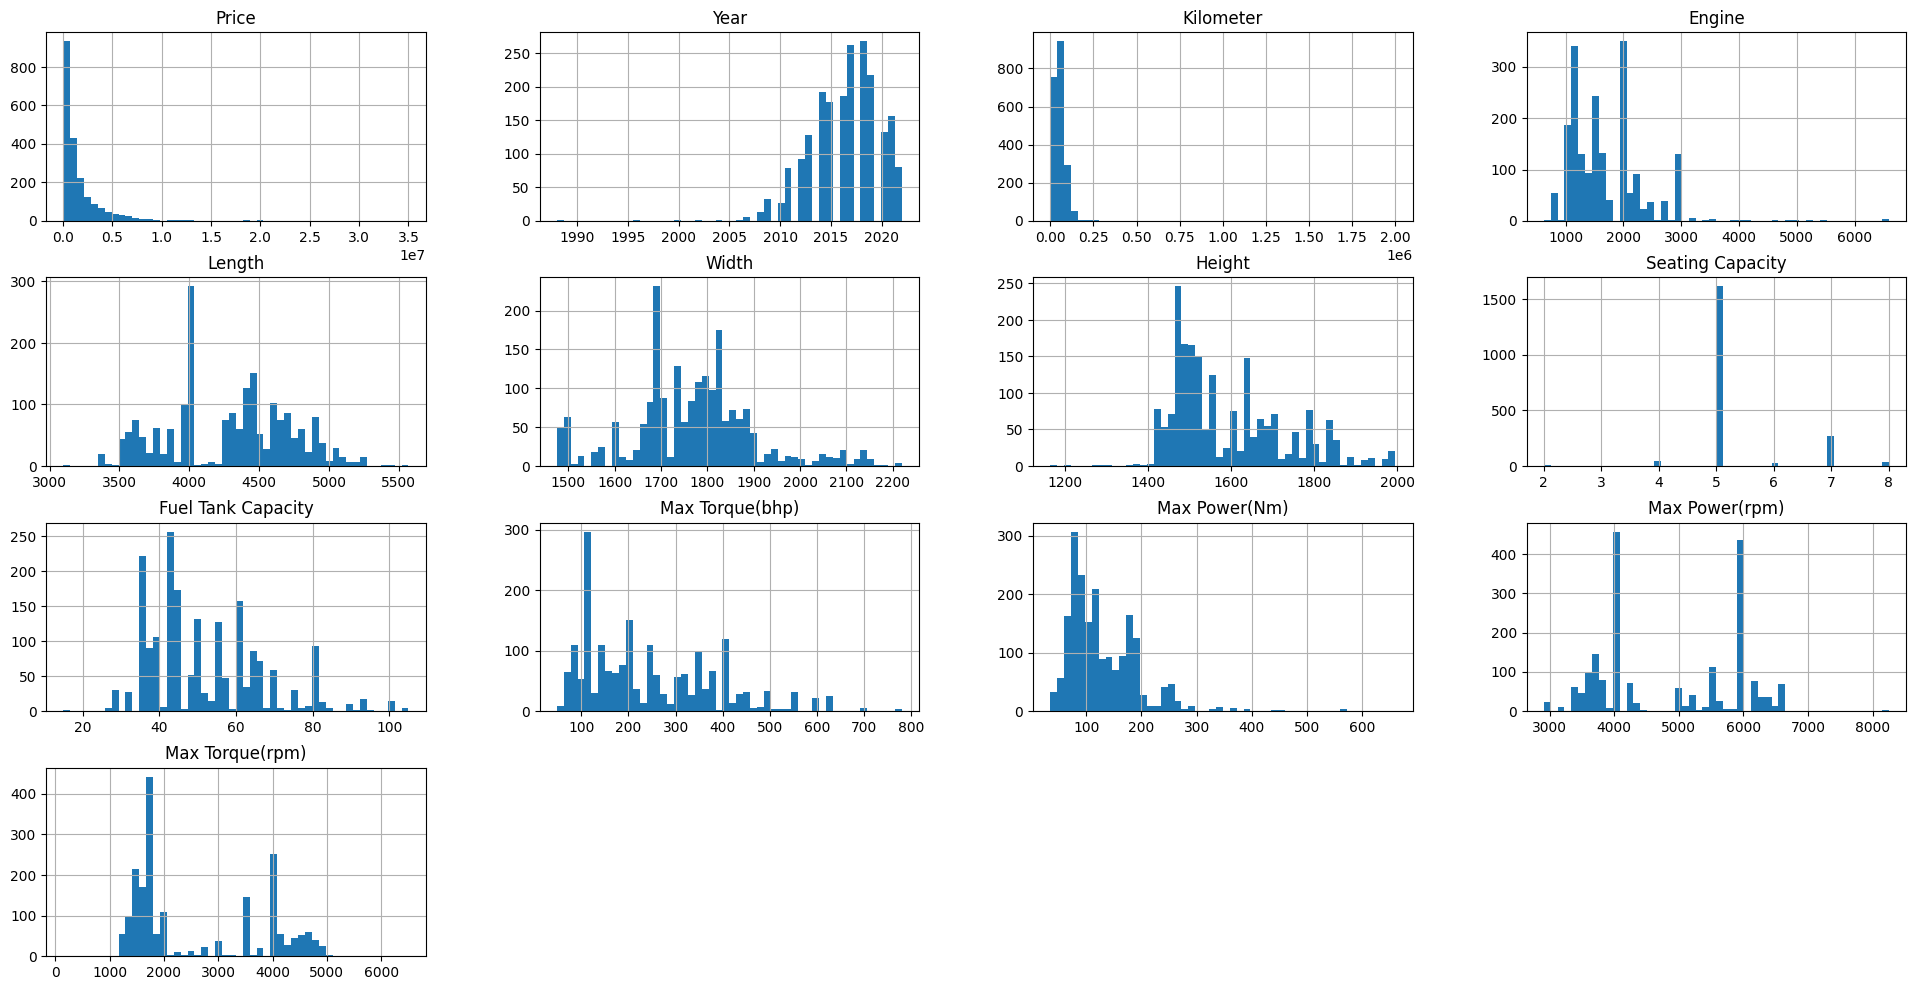

In [343]:
data.hist(bins=50, figsize=(24,12))

<Axes: xlabel='Max Power(Nm)', ylabel='Price'>

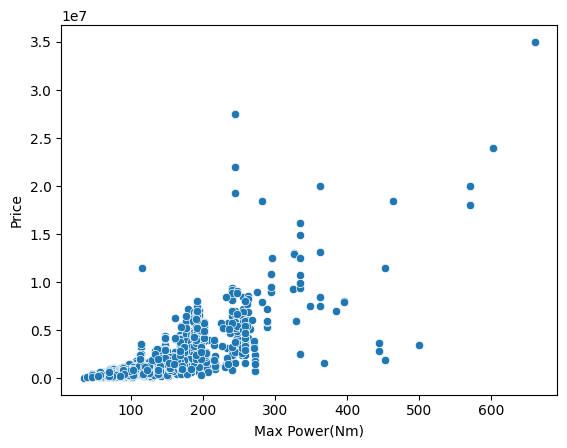

In [344]:
import seaborn as sns
sns.scatterplot(x=data['Max Power(Nm)'], y=data['Price'])

In [345]:
corr = data.corr(numeric_only=True)
corr['Price'].sort_values(ascending=False)
data = data[data["Kilometer"] > 1]

array([[<Axes: xlabel='Price', ylabel='Price'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Price'>,
        <Axes: xlabel='Width', ylabel='Price'>,
        <Axes: xlabel='Length', ylabel='Price'>,
        <Axes: xlabel='Year', ylabel='Price'>,
        <Axes: xlabel='Max Power(rpm)', ylabel='Price'>,
        <Axes: xlabel='Max Torque(rpm)', ylabel='Price'>,
        <Axes: xlabel='Max Power(Nm)', ylabel='Price'>,
        <Axes: xlabel='Max Torque(bhp)', ylabel='Price'>,
        <Axes: xlabel='Kilometer', ylabel='Price'>],
       [<Axes: xlabel='Price', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Width', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Length', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Year', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Max Power(rpm)', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Max Torque(rpm)', ylabel='Fuel Tank Capacity'>,
      

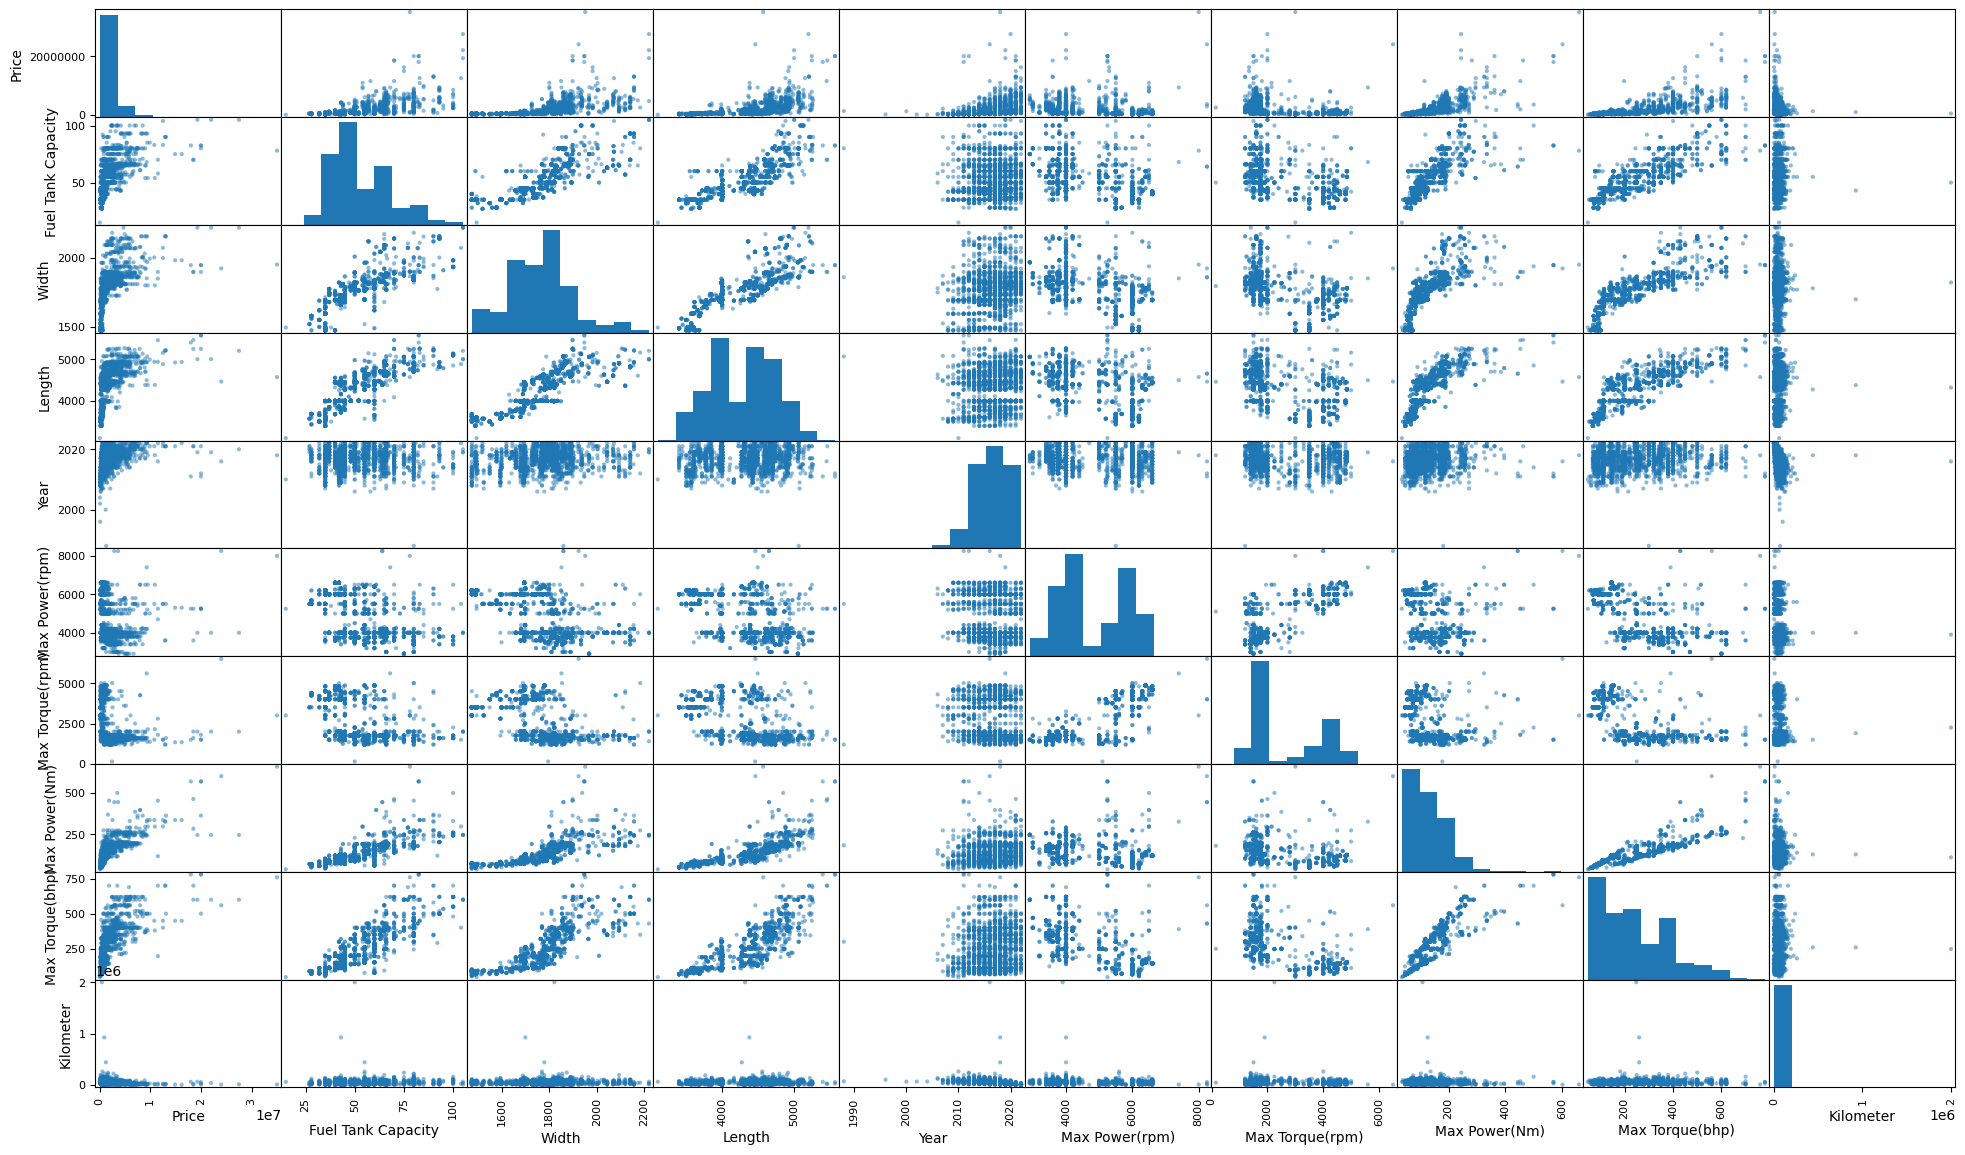

In [346]:
feat =  ['Price', 'Fuel Tank Capacity', 'Width', 'Length', 'Year', 'Max Power(rpm)', 'Max Torque(rpm)', 'Max Power(Nm)', 'Max Torque(bhp)', 'Kilometer']
scatter_matrix(data[feat], figsize=(24,14))

In [347]:
data.Price

0        505000
1        450000
2        220000
3        799000
4       1950000
         ...   
2054     850000
2055     275000
2056     240000
2057    4290000
2058     670000
Name: Price, Length: 2056, dtype: int64

In [348]:
data["Price"] = np.log(data["Price"])
data["Kilometer"] = np.log1p(data["Kilometer"])
data["Max Power(Nm)"] = np.log(data["Max Power(Nm)"])

In [349]:
data["Kilometer"].sort_values().head(10)

2044    4.330733
1563    6.216606
387     6.398595
1506    6.908755
1533    7.005789
1208    7.170888
741     7.170888
1111    7.226209
372     7.313887
320     7.438972
Name: Kilometer, dtype: float64

In [350]:
data[data["Kilometer"] < 1]["Kilometer"]

Series([], Name: Kilometer, dtype: float64)

In [351]:
data["Volume"] = data["Length"] * data["Width"] * data["Height"]
data["KPY"] = data["Kilometer"]/(2024-data["Year"])
len(data)

2056

In [352]:
cor = data.corr(numeric_only=True)
cor["Price"].sort_values(ascending=False)

Price                 1.000000
Max Power(Nm)         0.858985
Max Torque(bhp)       0.815669
Width                 0.776018
Length                0.766923
Fuel Tank Capacity    0.733685
Volume                0.722833
Engine                0.704739
Year                  0.505446
KPY                   0.454768
Height                0.172273
Seating Capacity      0.099105
Kilometer            -0.312636
Max Power(rpm)       -0.407582
Max Torque(rpm)      -0.502918
Name: Price, dtype: float64

array([[<Axes: xlabel='Price', ylabel='Price'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Price'>,
        <Axes: xlabel='Width', ylabel='Price'>,
        <Axes: xlabel='Length', ylabel='Price'>,
        <Axes: xlabel='Year', ylabel='Price'>,
        <Axes: xlabel='Max Power(rpm)', ylabel='Price'>,
        <Axes: xlabel='Max Torque(rpm)', ylabel='Price'>,
        <Axes: xlabel='Max Power(Nm)', ylabel='Price'>,
        <Axes: xlabel='Max Torque(bhp)', ylabel='Price'>,
        <Axes: xlabel='KPY', ylabel='Price'>],
       [<Axes: xlabel='Price', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Width', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Length', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Year', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Max Power(rpm)', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Max Torque(rpm)', ylabel='Fuel Tank Capacity'>,
        <Axe

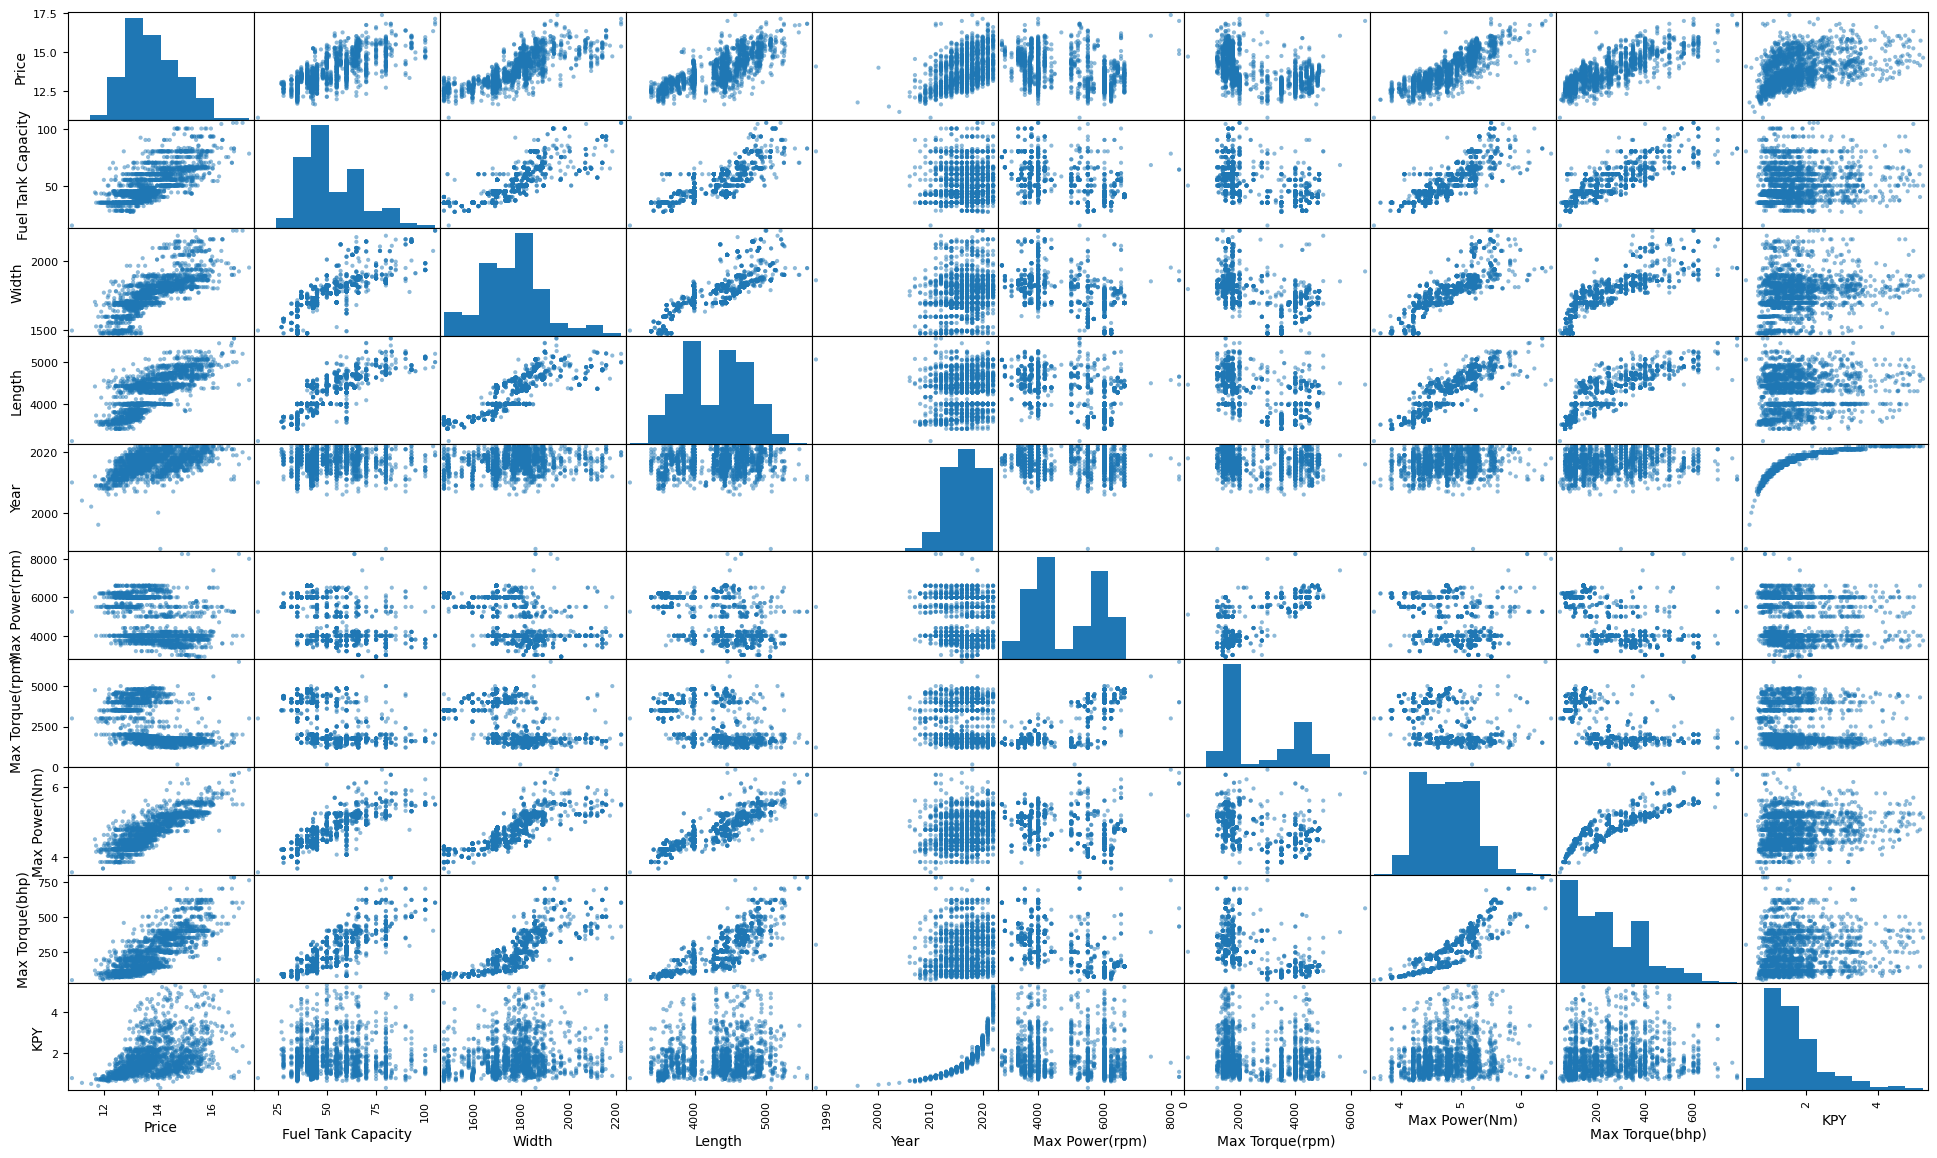

In [353]:
feat =  ['Price', 'Fuel Tank Capacity', 'Width', 'Length', 'Year', 'Max Power(rpm)', 'Max Torque(rpm)', 'Max Power(Nm)', 'Max Torque(bhp)', 'KPY']
scatter_matrix(data[feat], figsize=(24,14))

## BASELINE MODEL ##

In [354]:
data["Price_cat"] = pd.qcut(data['Price'], q=4, labels=[1,2,3,4])
train_set, test_set = train_test_split(data, train_size=0.8, test_size=0.2, random_state=42, stratify=data["Price_cat"])

In [355]:
for i in [train_set, test_set]:
  i.drop(columns=['Price_cat'], inplace=True)

In [356]:
train_X = train_set.drop(["Max Power", "Max Torque", "Price", "Location", "Color"], axis=1)
train_y = train_set["Price"]
test_X = test_set.drop(["Max Power", "Max Torque", "Price", "Location", "Color"], axis=1)
test_y = test_set.Price
categorical_cols = train_X.select_dtypes(include='object').columns.tolist()
numerical_cols = train_X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [357]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

pipeline.fit(train_X, train_y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [358]:
predict = pipeline.predict(train_X)
predict = np.exp(predict)
root_mean_squared_error(np.exp(train_y), predict)

776738.3236542586

In [359]:
predict = pipeline.predict(test_X)
predict = np.exp(predict)
rmse = root_mean_squared_error(np.exp(test_y), predict)
rmse

873643.0068031037

In [360]:
rmse / np.exp(test_y).mean() * 100

np.float64(51.85572109264274)

In [361]:
preprocessor2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numerical_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

pipeline2 = Pipeline([
    ('preprocessor', preprocessor2),
    ('randomforest', RandomForestRegressor(random_state=42))
])
pipeline2.fit(train_X, train_y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('randomforest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [362]:
predict2 = np.exp(pipeline2.predict(train_X))
rmse2 = root_mean_squared_error(np.exp(train_y), predict2)
rmse2

555845.1697295154

In [363]:
predict2 = np.exp(pipeline2.predict(test_X))
rmse2 = root_mean_squared_error(np.exp(test_y), predict2)
rmse2

907120.6598528867

In [364]:
rmse2 / np.exp(test_y).mean() * 100

np.float64(53.84281173019998)

In [365]:
pipeline2[:-1].transform(train_X).shape

(1644, 69)

In [366]:
train_X.columns.tolist()

['Make',
 'Year',
 'Kilometer',
 'Fuel Type',
 'Transmission',
 'Owner',
 'Seller Type',
 'Engine',
 'Drivetrain',
 'Length',
 'Width',
 'Height',
 'Seating Capacity',
 'Fuel Tank Capacity',
 'Max Torque(bhp)',
 'Max Power(Nm)',
 'Max Power(rpm)',
 'Max Torque(rpm)',
 'Volume',
 'KPY']

## TRAIN MODEL ##

In [367]:
num_pipeline = Pipeline([
    ('knn',KNNImputer(n_neighbors=4)),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('SI', SimpleImputer(strategy='most_frequent')),
    ('OH', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [368]:
log_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ('log', FunctionTransformer(np.log, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])
def calc(X):
    X = X[:, [0]]*X[:, [1]]*X[:, [2]]
    return X.reshape(-1,1)

def volume_name(function_transformer, feature_names_in):
    return ["volume"]

def volume():
    return Pipeline([
        ('impute',SimpleImputer(strategy='median')),
        ('function',FunctionTransformer(calc, feature_names_out=volume_name)),
        ('standard',StandardScaler())
    ])
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"] 
def ratio(X):
    return X[:,[0]] / (2024-X[:,[1]])
def ratio_pipeline():
    return Pipeline([
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('trans',FunctionTransformer(ratio, feature_names_out=ratio_name))

    ])

In [369]:
preprocessing = ColumnTransformer([
    ("KYP", ratio_pipeline(), ["Kilometer", "Year"]),
    ('Volume', volume(), ["Length", "Width", "Height"]),
    ('log', log_pipeline, ['Kilometer', "Fuel Tank Capacity", "Engine", "Max Power(Nm)", "Max Torque(bhp)"]),
    ('num', num_pipeline, ["Year", "Max Power(rpm)", "Max Torque(rpm)", "Seating Capacity"] ),
    ("cat", cat_pipeline, categorical_cols)
], remainder='drop')

In [370]:
model1 = Pipeline([
    ("preprocess", preprocessing),
    ("Random", RandomForestRegressor(n_estimators= 200, random_state=42))
])
model1.fit(train_X, train_y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('Random', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('KYP', ...), ('Volume', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [371]:
pred = model1.predict(train_X)
root_mean_squared_error(np.exp(train_y), np.exp(pred))

537056.879070888

In [372]:
pred = model1.predict(test_X)
root_mean_squared_error(np.exp(test_y), np.exp(pred))

991902.7053521514

In [373]:
corss = -cross_val_score(model1, train_X, train_y,
                         scoring='neg_root_mean_squared_error', cv=10)

In [374]:
corss.mean()

np.float64(0.24476540473649222)

In [375]:
# log scale test RMSE for comparison
root_mean_squared_error(test_y, model1.predict(test_X))

0.25043742032711935

In [382]:
param_grid = [
    {'Random__n_estimators': [100, 200, 300],
     'preprocess__num__knn__n_neighbors': [ 4, 6, 8],
     'Random__max_depth': [5, 10],
     'Random__min_samples_leaf': [1, 3],
     'Random__max_features': [2, 4, 9 ]
     },
    {'Random__n_estimators': [150, 250],
     'preprocess__num__knn__n_neighbors': [ 5, 13],
     'Random__max_depth': [9, 32],
     'Random__min_samples_leaf': [2,9],
     'Random__max_features': [4, 11]}
]

grid_search = GridSearchCV(model1, param_grid, cv=2,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(train_X, train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'Random__max_depth': [5, 10], 'Random__max_features': [2, 4, ...], 'Random__min_samples_leaf': [1, 3], 'Random__n_estimators': [100, 200, ...], ...}, {'Random__max_depth': [9, 32], 'Random__max_features': [4, 11], 'Random__min_samples_leaf': [2, 9], 'Random__n_estimators': [150, 250, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged

In [408]:
param_gridR = [{
    'Random__n_estimators': randint(100, 400),
    'Random__max_depth': randint(5, 30),
    'Random__min_samples_leaf': randint(1, 10),
    'Random__max_features': randint(2, 20),
    'preprocess__num__knn__n_neighbors': randint(3, 15)
    }
]
random_search = RandomizedSearchCV(model1, param_gridR, cv=3, n_iter=10, n_jobs=-1,
                                   scoring='neg_root_mean_squared_error')

In [409]:
grid_search.best_params_

{'Random__max_depth': 10,
 'Random__max_features': 9,
 'Random__min_samples_leaf': 1,
 'Random__n_estimators': 300,
 'preprocess__num__knn__n_neighbors': 6}

In [410]:
grid_search.best_score_

np.float64(-0.27482329341125455)

In [411]:
random_search.fit(train_X, train_y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'Random__max_depth': <scipy.stats....002560E32FE00>, 'Random__max_features': <scipy.stats....002560E32FA10>, 'Random__min_samples_leaf': <scipy.stats....002560E32FD90>, 'Random__n_estimators': <scipy.stats....002560E32F8C0>, ...}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits

In [412]:
random_search.best_params_

{'Random__max_depth': 20,
 'Random__max_features': 10,
 'Random__min_samples_leaf': 1,
 'Random__n_estimators': 181,
 'preprocess__num__knn__n_neighbors': 11}

In [413]:
random_search.best_score_

np.float64(-0.25783342724100317)

In [414]:
random_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('Random', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('KYP', ...), ('Volume', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [416]:
final_model = random_search.best_estimator_
pred = random_search.predict(test_X)

In [417]:
root_mean_squared_error(np.exp(test_y), np.exp(pred))

1002753.2831398039

In [429]:
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import uniform
grad = Pipeline([
    ('preprocess', preprocessing),
    ('grad', GradientBoostingRegressor())
])

param_gridR = [{
    'grad__learning_rate': uniform(0.01, 0.6),
    'grad__n_estimators': randint(50,200),
    'grad__max_depth': randint(3, 10),
    'grad__alpha': uniform(0.1,0.9),
    'preprocess__num__knn__n_neighbors': randint(3, 15)
    }
]
random_search_gradient = RandomizedSearchCV(grad, param_gridR, cv=3, n_iter=10, n_jobs=-1,
                                   scoring='neg_root_mean_squared_error')

In [430]:
random_search_gradient.fit(train_X, train_y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'grad__alpha': <scipy.stats....002561679A550>, 'grad__learning_rate': <scipy.stats....002561679AE50>, 'grad__max_depth': <scipy.stats....0025616925550>, 'grad__n_estimators': <scipy.stats....0025616924A60>, ...}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same 

In [431]:
random_search_gradient.best_params_

{'grad__alpha': np.float64(0.39969017621599134),
 'grad__learning_rate': np.float64(0.22687011195481852),
 'grad__max_depth': 3,
 'grad__n_estimators': 199,
 'preprocess__num__knn__n_neighbors': 12}

In [434]:
best_model = random_search_gradient.best_estimator_
predict = best_model.predict(test_X)
root_mean_squared_error(np.exp(test_y), np.exp(predict))

699901.1463253791

In [438]:
import joblib
joblib.dump(best_model, "EXERCISE7.pkl")

['EXERCISE7.pkl']

In [439]:
model = joblib.load("EXERCISE7.pkl")
model.predict(test_X)

array([14.28915017, 14.71135034, 13.45114746, 13.83989561, 15.28794642,
       13.23831027, 12.29775165, 14.31319562, 13.00027809, 13.28780319,
       12.86934532, 15.40443239, 15.40729673, 15.65247364, 13.68232153,
       13.85566463, 14.81078744, 13.59668676, 13.21421252, 13.35407593,
       14.83677897, 13.63116838, 13.07961802, 13.90481769, 15.34875667,
       14.30377163, 14.26444703, 12.76547986, 13.87879864, 15.08361365,
       14.84018302, 14.28302561, 13.27529387, 15.23064336, 13.91405413,
       13.77375648, 14.445536  , 14.99849407, 13.05030315, 13.13867389,
       12.91109794, 13.53626831, 13.32302774, 16.15102233, 13.33559726,
       14.50593367, 14.36868091, 13.34817626, 13.39064893, 13.62593381,
       13.17373139, 13.314262  , 13.39309643, 13.9462638 , 13.89856521,
       13.68557205, 13.73705121, 15.01901215, 12.41455027, 13.51581445,
       14.50746154, 15.79828642, 12.57754927, 12.92995088, 13.74585963,
       12.89651672, 13.79854523, 14.74071145, 12.96788115, 14.57